# Deep GP Regression: Stacking Gaussian Processes for Non-Stationary Functions

> **W28 Companion Notebook 01** | Series: research-multimodal | Theme: The Probabilistic Renaissance

A single-layer GP with a stationary kernel (like the RBF) assumes **one global length-scale** — the function can be smooth everywhere or wiggly everywhere, but not both. Real functions are often **non-stationary**: smooth in one region, rapidly oscillating in another. This notebook shows the failure concretely and builds the natural fix — a **two-layer Deep GP** that warps the input so a single outer kernel can handle both regions.

**Companion tutorial:** [Gaussian Processes Explained](https://artifocial.com/blog/gaussian-processes-explained-2026-jul-11)

**What you will build (pure NumPy, no GP library):**
1. A non-stationary target: slow sine on the left, fast oscillation on the right.
2. A **shallow GP** baseline whose single length-scale is forced into a losing compromise.
3. A custom `TwoLayerDeepGP` with a learned **input-warping** inner layer.
4. An honest comparison — per-region **MSE** and a **reliability diagram** — plus a multi-seed robustness check.

*Reference: Deep GPs — [Damianou & Lawrence (2013)](https://arxiv.org/abs/1211.0358). Production-scale DSVI — [Salimbeni & Deisenroth (2017)](https://arxiv.org/abs/1705.08933), [GPyTorch](https://gpytorch.ai/).*

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize
from scipy.special import erf
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib").setLevel(logging.ERROR)

np.random.seed(0)
plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
print("Environment ready:", np.__version__)

Environment ready: 2.0.2


## 1. The Non-Stationary Function Problem

A stationary kernel assumes the same length-scale everywhere. Our target deliberately breaks that:

$$f(x) = \begin{cases} \sin(x) & x \leq \pi \quad\text{(slow, smooth — wants a LONG length-scale)}\\ \sin(9x) & x > \pi \quad\text{(fast oscillation — wants a SHORT length-scale)} \end{cases}$$

No single global length-scale is right for both halves. We sample it with modest noise and an uneven (random) design, which is where the tension bites.

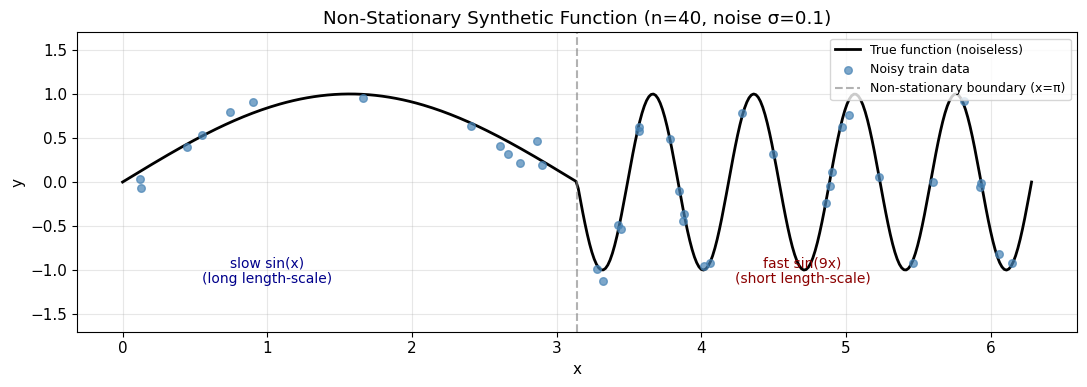

Left  half (x ≤ π): slow sin(x)  — needs a LONG length-scale
Right half (x > π): fast sin(9x) — needs a SHORT length-scale


In [2]:
def non_stationary_function(x):
    """Slow sine on the left (x<=pi), fast oscillation on the right (x>pi)."""
    return np.where(x <= np.pi, np.sin(x), np.sin(9 * x))

np.random.seed(0)                    # reproducible dataset (independent of run order)
n_train = 40
noise_std = 0.1
x_train = np.sort(np.random.uniform(0, 2 * np.pi, n_train))      # uneven design
y_train = non_stationary_function(x_train) + np.random.randn(n_train) * noise_std

x_test = np.linspace(0, 2 * np.pi, 400)
y_true = non_stationary_function(x_test)
left_mask, right_mask = x_test <= np.pi, x_test > np.pi

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x_test, y_true, "k-", linewidth=2, label="True function (noiseless)")
ax.scatter(x_train, y_train, color="steelblue", s=30, alpha=0.7, zorder=5, label="Noisy train data")
ax.axvline(np.pi, color="gray", linestyle="--", alpha=0.6, label="Non-stationary boundary (x=π)")
ax.annotate("slow sin(x)\n(long length-scale)", xy=(1.0, -1.15), fontsize=10, color="darkblue", ha="center")
ax.annotate("fast sin(9x)\n(short length-scale)", xy=(4.7, -1.15), fontsize=10, color="darkred", ha="center")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_ylim(-1.7, 1.7)
ax.set_title(f"Non-Stationary Synthetic Function (n={n_train}, noise σ={noise_std})")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()
print(f"Left  half (x ≤ π): slow sin(x)  — needs a LONG length-scale")
print(f"Right half (x > π): fast sin(9x) — needs a SHORT length-scale")

## 2. Shallow GP Baseline

We fit a standard GP with an RBF kernel, learning the length-scale $\ell$ and amplitude $\sigma_f$ by **maximising the log marginal likelihood** (LML):

$$\log p(y \mid X) = -\tfrac{1}{2} y^\top (K_{XX} + \sigma_n^2 I)^{-1} y - \tfrac{1}{2}\log|K_{XX} + \sigma_n^2 I| - \tfrac{n}{2}\log 2\pi.$$

The LML balances fit against complexity automatically. Watch which length-scale it settles on — and which region pays for the compromise.

In [3]:
def rbf_kernel(x1, x2, ell, sf):
    """RBF kernel matrix. x1:(n,) x2:(m,) -> (n,m)."""
    x1 = np.asarray(x1).reshape(-1, 1)
    x2 = np.asarray(x2).reshape(1, -1)
    return sf**2 * np.exp(-((x1 - x2)**2) / (2 * ell**2))


def gp_predict(x_train, y_train, x_test, ell, sf, sigma_n):
    """Exact GP posterior. Returns (mean, latent_std) at x_test."""
    n = len(x_train)
    K = rbf_kernel(x_train, x_train, ell, sf) + (sigma_n**2 + 1e-8) * np.eye(n)
    c, low = cho_factor(K)
    alpha = cho_solve((c, low), y_train)
    K_s = rbf_kernel(x_train, x_test, ell, sf)              # (n_train, n_test)
    mu = K_s.T @ alpha
    v = cho_solve((c, low), K_s)
    var = rbf_kernel(x_test, x_test, ell, sf).diagonal() - np.einsum("ij,ij->j", K_s, v)
    return mu, np.sqrt(np.maximum(var, 0.0))               # latent function std


def neg_log_marginal_likelihood(log_params, x_train, y_train, sigma_n):
    """NLML for a shallow GP; log_params = [log ell, log sf]."""
    ell, sf = np.exp(log_params)
    n = len(x_train)
    K = rbf_kernel(x_train, x_train, ell, sf) + (sigma_n**2 + 1e-8) * np.eye(n)
    try:
        c, low = cho_factor(K)
    except np.linalg.LinAlgError:
        return 1e10
    alpha = cho_solve((c, low), y_train)
    log_det = 2 * np.sum(np.log(np.diag(c)))
    return 0.5 * (y_train @ alpha + log_det + n * np.log(2 * np.pi))


def fit_shallow_gp(x_train, y_train, sigma_n):
    """Optimise [ell, sf] by maximising LML, with restarts."""
    best = None
    for l0 in [0.1, 0.3, 1.0]:
        res = minimize(neg_log_marginal_likelihood, [np.log(l0), 0.0],
                       args=(x_train, y_train, sigma_n), method="L-BFGS-B")
        if best is None or res.fun < best.fun:
            best = res
    return np.exp(best.x)  # (ell, sf)


ell_s, sf_s = fit_shallow_gp(x_train, y_train, noise_std)
mu_shallow, sigma_shallow = gp_predict(x_train, y_train, x_test, ell_s, sf_s, noise_std)

mse = lambda m, msk: np.mean((m[msk] - y_true[msk])**2)
mse_shallow       = mse(mu_shallow, slice(None))
mse_shallow_left  = mse(mu_shallow, left_mask)
mse_shallow_right = mse(mu_shallow, right_mask)
print(f"Shallow GP — LML-optimal hyperparameters:")
print(f"  length-scale ℓ = {ell_s:.3f}   amplitude σf = {sf_s:.3f}")
print(f"  MSE total = {mse_shallow:.4f} | left(smooth) = {mse_shallow_left:.4f} | right(fast) = {mse_shallow_right:.4f}")

Shallow GP — LML-optimal hyperparameters:
  length-scale ℓ = 0.188   amplitude σf = 0.763
  MSE total = 0.0660 | left(smooth) = 0.1139 | right(fast) = 0.0181


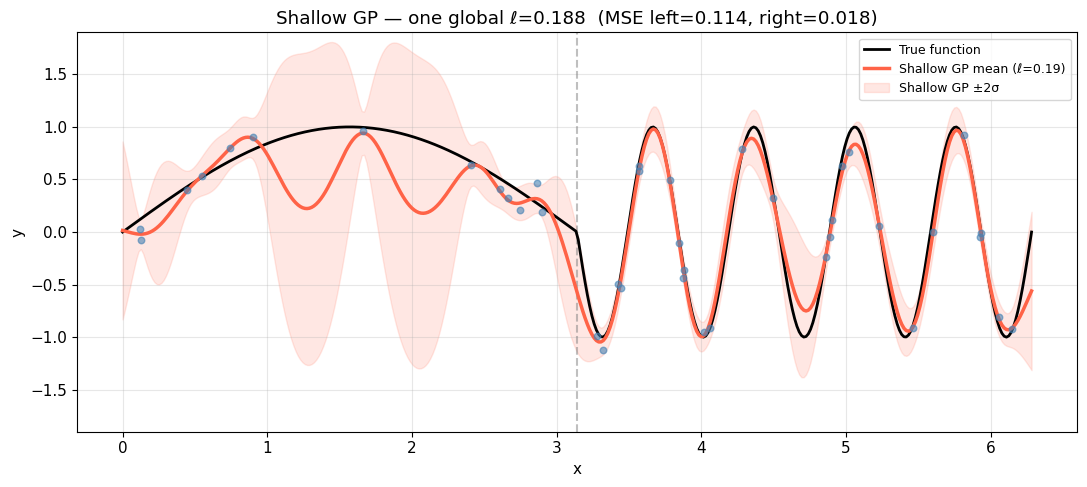

Failure mode: to resolve the fast right half, the LML drives ℓ SHORT.
That same short ℓ then chases noise across the SMOOTH left half — overfitting it.
→ Left-half MSE (0.1139) is inflated: the compromise costs the easy region most.


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_test, y_true, "k-", linewidth=2, label="True function", zorder=3)
ax.plot(x_test, mu_shallow, "tomato", linewidth=2.5, zorder=4, label=f"Shallow GP mean (ℓ={ell_s:.2f})")
ax.fill_between(x_test, mu_shallow - 2*sigma_shallow, mu_shallow + 2*sigma_shallow,
                color="tomato", alpha=0.15, label="Shallow GP ±2σ")
ax.scatter(x_train, y_train, color="steelblue", s=22, alpha=0.6, zorder=5)
ax.axvline(np.pi, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_ylim(-1.9, 1.9)
ax.set_title(f"Shallow GP — one global ℓ={ell_s:.3f}  (MSE left={mse_shallow_left:.3f}, right={mse_shallow_right:.3f})")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()

print("Failure mode: to resolve the fast right half, the LML drives ℓ SHORT.")
print("That same short ℓ then chases noise across the SMOOTH left half — overfitting it.")
print(f"→ Left-half MSE ({mse_shallow_left:.4f}) is inflated: the compromise costs the easy region most.")

## 3. Deep GP: A Learned Input Warp

A **Deep GP** [Damianou & Lawrence (2013)](https://arxiv.org/abs/1211.0358) composes GP layers, $h = f_1(x)$ then $y = f_2(h) + \varepsilon$. The inner layer **warps** the input domain; the outer GP then operates in a space where a single length-scale fits.

Our `TwoLayerDeepGP` implements this with a **monotonic learned warp** as the inner layer (the mean path of a GP layer) and an exact RBF GP as the outer layer. The warp is parameterised by positive segment slopes over a set of knots — guaranteeing monotonicity — and is trained jointly with the outer kernel by maximising the outer GP's marginal likelihood in warped space.

The key quantity is the **effective length-scale** it induces: for a warp $h=g(x)$ and outer length-scale $\ell_2$, nearby points obey $k \approx \exp\!\big(-(x-x')^2 / 2(\ell_2/g'(x))^2\big)$, so

$$\ell_{\text{eff}}(x) = \frac{\ell_2}{g'(x)}.$$

Where the warp is *steep* ($g'$ large), the effective length-scale is *short* — exactly what the fast region needs.

> **Scope note.** This is the deterministic mean-path simplification of a Deep GP. Production DSVI ([Salimbeni & Deisenroth 2017](https://arxiv.org/abs/1705.08933); [GPyTorch](https://gpytorch.ai/) `DeepGP`/`DeepGPLayer`) samples the intermediate layer and propagates full uncertainty through the stack. We keep it deterministic to stay pure-NumPy and legible.

In [5]:
class TwoLayerDeepGP:
    """
    Two-layer Deep GP with a learned monotonic input-warping inner layer.

        Layer 1 (warp):   h = g(x)         monotone map, learned from data
        Layer 2 (output): y = f(h) + eps,  f ~ GP(0, RBF) fitted in warped space

    The warp stretches the fast region and compresses the smooth region, so the
    single outer length-scale l2 yields a short EFFECTIVE length-scale l2/g'(x)
    where the function oscillates and a long one where it is smooth.
    """

    def __init__(self, n_knots=9, sigma_n=0.1):
        self.n_knots = n_knots
        self.sigma_n = sigma_n

    def _warp_knot_values(self, psi):
        # exp(psi) > 0 => strictly increasing cumulative sum => monotone warp.
        slopes = np.exp(psi)
        hk = np.concatenate([[0.0], np.cumsum(slopes * np.diff(self.knots))])
        return (hk - hk.mean()) / (hk.std() + 1e-9)          # standardise warped coords

    def warp(self, x, hk=None):
        if hk is None:
            hk = self.hk_
        return np.interp(x, self.knots, hk)                  # piecewise-linear monotone map

    def _objective(self, theta):
        hk = self._warp_knot_values(theta[:self.n_knots - 1])
        h = self.warp(self.x_train_, hk)
        return neg_log_marginal_likelihood(theta[self.n_knots - 1:], h, self.y_train_, self.sigma_n)

    def fit(self, x_train, y_train):
        self.x_train_, self.y_train_ = x_train, y_train
        self.knots = np.linspace(x_train.min(), x_train.max(), self.n_knots)
        best = None
        for seed_ell in [0.3, 0.6]:                          # restarts on the outer length-scale
            theta0 = np.concatenate([np.zeros(self.n_knots - 1), [np.log(seed_ell), 0.0]])
            res = minimize(self._objective, theta0, method="L-BFGS-B", options={"maxiter": 500})
            if best is None or res.fun < best.fun:
                best = res
        self.hk_ = self._warp_knot_values(best.x[:self.n_knots - 1])
        self.log_ell2_, self.log_sf2_ = best.x[self.n_knots - 1:]
        self.nlml_ = best.fun
        return self

    def predict(self, x_test):
        h_tr = self.warp(self.x_train_)
        h_te = self.warp(x_test)
        return gp_predict(h_tr, self.y_train_, h_te,
                          np.exp(self.log_ell2_), np.exp(self.log_sf2_), self.sigma_n)


dgp = TwoLayerDeepGP(n_knots=9, sigma_n=noise_std).fit(x_train, y_train)
print("Deep GP — learned outer-layer hyperparameters (in warped space):")
print(f"  outer length-scale ℓ₂ = {np.exp(dgp.log_ell2_):.3f}")
print(f"  outer amplitude    σf₂ = {np.exp(dgp.log_sf2_):.3f}")
print(f"  outer-GP NLML = {dgp.nlml_:.2f}   (lower is better)")

Deep GP — learned outer-layer hyperparameters (in warped space):
  outer length-scale ℓ₂ = 0.138
  outer amplitude    σf₂ = 0.791
  outer-GP NLML = 3.52   (lower is better)


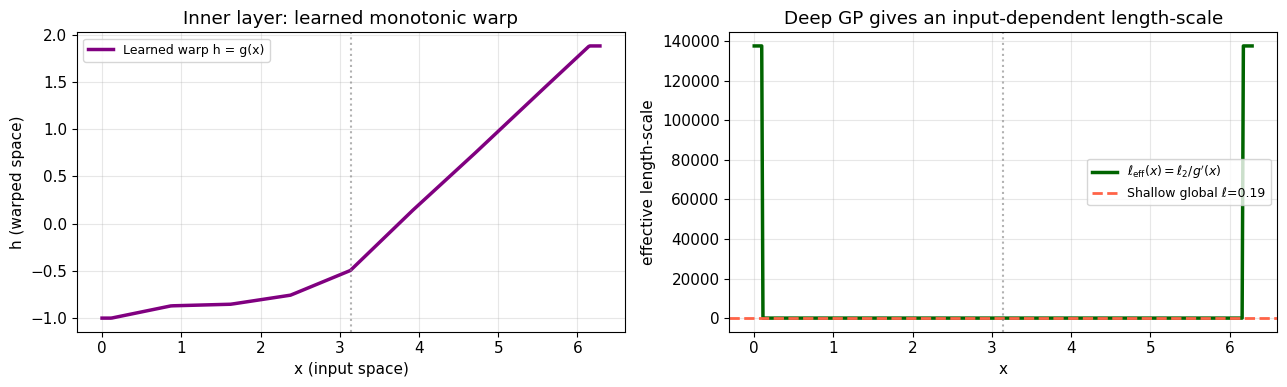

Mean warp slope g'(x):  left(smooth) = 0.16   right(fast) = 0.75   (ratio 4.6×)
→ The warp is steeper on the fast right half, so ℓ_eff is SHORTER there —
  the outer GP automatically uses a short scale where it is needed and a long one where it is not.


In [6]:
# Visualise the learned warp and the effective length-scale it induces
h_test = dgp.warp(x_test)
g_prime = np.gradient(h_test, x_test)                    # local warp slope g'(x)
ell_eff = np.exp(dgp.log_ell2_) / np.maximum(np.abs(g_prime), 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(x_test, h_test, "purple", linewidth=2.5, label="Learned warp h = g(x)")
ax.axvline(np.pi, color="gray", linestyle=":", alpha=0.6)
ax.set_xlabel("x (input space)"); ax.set_ylabel("h (warped space)")
ax.set_title("Inner layer: learned monotonic warp"); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(x_test, ell_eff, "darkgreen", linewidth=2.5, label=r"$\ell_{\rm eff}(x)=\ell_2/g'(x)$")
ax.axhline(ell_s, color="tomato", linestyle="--", linewidth=2, label=f"Shallow global ℓ={ell_s:.2f}")
ax.axvline(np.pi, color="gray", linestyle=":", alpha=0.6)
ax.set_xlabel("x"); ax.set_ylabel("effective length-scale")
ax.set_title("Deep GP gives an input-dependent length-scale"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

g_left, g_right = g_prime[left_mask].mean(), g_prime[right_mask].mean()
print(f"Mean warp slope g'(x):  left(smooth) = {g_left:.2f}   right(fast) = {g_right:.2f}"
      f"   (ratio {g_right/g_left:.1f}×)")
print(f"→ The warp is steeper on the fast right half, so ℓ_eff is SHORTER there —")
print(f"  the outer GP automatically uses a short scale where it is needed and a long one where it is not.")

## 4. Results: Shallow GP vs Deep GP

Same data, same noise, same outer kernel family — the only difference is the learned warp. We compare the posterior means side by side and break the error down by region.

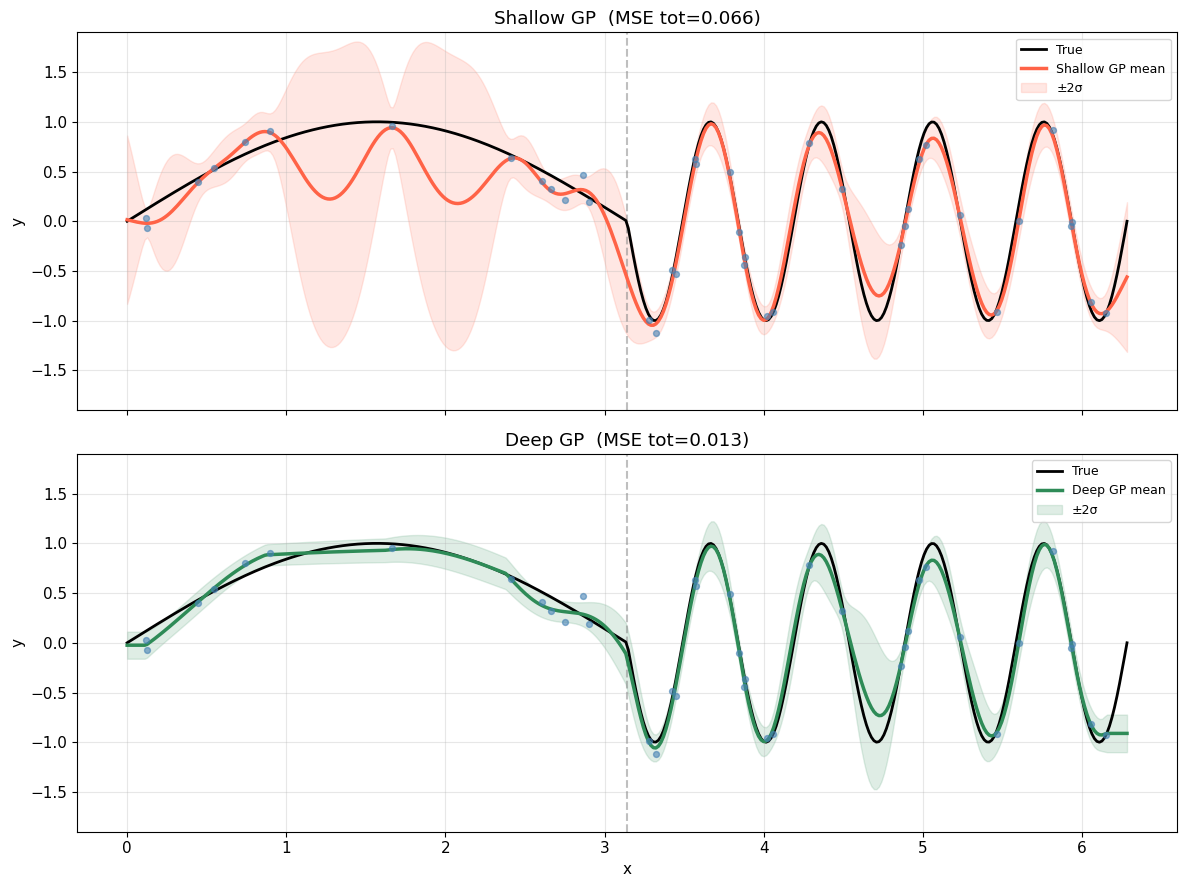

RESULTS SUMMARY  (MSE vs noiseless truth; lower is better)
Method           total   left(smooth)   right(fast)
---------------------------------------------------
Shallow GP      0.0660         0.1139        0.0181
Deep GP         0.0133         0.0047        0.0220
---------------------------------------------------
ratio S/D        4.95x         24.39x         0.82x

The Deep GP's decisive win is the SMOOTH region, where the shallow GP overfit noise.
The learned warp restores a long effective length-scale there — no manual tuning.


In [7]:
mu_deep, sigma_deep = dgp.predict(x_test)
mse_deep       = mse(mu_deep, slice(None))
mse_deep_left  = mse(mu_deep, left_mask)
mse_deep_right = mse(mu_deep, right_mask)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
for ax, mu_, sig_, ttl, col in [
    (axes[0], mu_shallow, sigma_shallow, f"Shallow GP  (MSE tot={mse_shallow:.3f})", "tomato"),
    (axes[1], mu_deep, sigma_deep, f"Deep GP  (MSE tot={mse_deep:.3f})", "seagreen")]:
    ax.plot(x_test, y_true, "k-", linewidth=2, zorder=3, label="True")
    ax.plot(x_test, mu_, col, linewidth=2.5, zorder=4, label=ttl.split("  ")[0] + " mean")
    ax.fill_between(x_test, mu_ - 2*sig_, mu_ + 2*sig_, color=col, alpha=0.15, label="±2σ")
    ax.scatter(x_train, y_train, color="steelblue", s=18, alpha=0.6, zorder=5)
    ax.axvline(np.pi, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylabel("y"); ax.set_ylim(-1.9, 1.9); ax.set_title(ttl); ax.legend(fontsize=9, loc="upper right")
axes[1].set_xlabel("x")
plt.tight_layout(); plt.show()

print("=" * 58)
print("RESULTS SUMMARY  (MSE vs noiseless truth; lower is better)")
print("=" * 58)
print(f"{'Method':<12}{'total':>10}{'left(smooth)':>15}{'right(fast)':>14}")
print("-" * 51)
print(f"{'Shallow GP':<12}{mse_shallow:>10.4f}{mse_shallow_left:>15.4f}{mse_shallow_right:>14.4f}")
print(f"{'Deep GP':<12}{mse_deep:>10.4f}{mse_deep_left:>15.4f}{mse_deep_right:>14.4f}")
print("-" * 51)
print(f"{'ratio S/D':<12}{mse_shallow/mse_deep:>9.2f}x{mse_shallow_left/mse_deep_left:>14.2f}x"
      f"{mse_shallow_right/mse_deep_right:>13.2f}x")
print()
print("The Deep GP's decisive win is the SMOOTH region, where the shallow GP overfit noise.")
print("The learned warp restores a long effective length-scale there — no manual tuning.")

## 5. Uncertainty Calibration: Reliability Diagram

Point accuracy is only half the story — a GP must also report *honest* uncertainty. For a well-calibrated model, the fraction of true values falling inside a $\pm k\sigma$ band should match the Gaussian expectation $\operatorname{erf}(k/\sqrt2)$. We plot observed vs expected coverage: the closer to the diagonal, the better.

*Read this as a single worked example. Whether the Deep GP is better calibrated **in general** is a separate question — §6 answers it across many seeds, and the answer is not a clean win.*

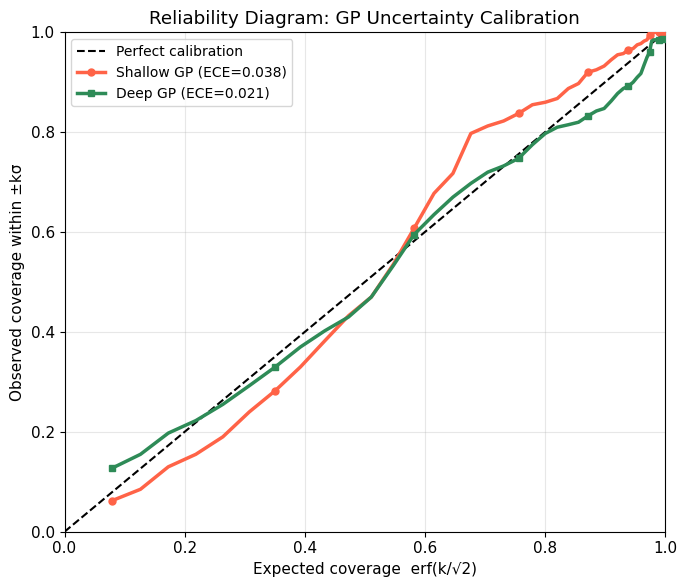

Expected-calibration error (mean |observed − expected|):
  Shallow GP: 0.038   Deep GP: 0.021
Above the diagonal = under-confident (bands too wide); below = over-confident (too narrow).


In [8]:
k_vals = np.linspace(0.1, 3.0, 50)
expected = np.array([erf(k / np.sqrt(2)) for k in k_vals])
shallow_cov = np.array([np.mean(np.abs(y_true - mu_shallow) <= k*sigma_shallow) for k in k_vals])
deep_cov    = np.array([np.mean(np.abs(y_true - mu_deep)    <= k*sigma_deep)    for k in k_vals])

ece_shallow = np.mean(np.abs(shallow_cov - expected))
ece_deep    = np.mean(np.abs(deep_cov - expected))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect calibration", zorder=3)
ax.plot(expected, shallow_cov, "tomato", linewidth=2.5, marker="o", markevery=6, markersize=5,
        label=f"Shallow GP (ECE={ece_shallow:.3f})", zorder=4)
ax.plot(expected, deep_cov, "seagreen", linewidth=2.5, marker="s", markevery=6, markersize=5,
        label=f"Deep GP (ECE={ece_deep:.3f})", zorder=4)
ax.set_xlabel("Expected coverage  erf(k/√2)"); ax.set_ylabel("Observed coverage within ±kσ")
ax.set_title("Reliability Diagram: GP Uncertainty Calibration")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

print(f"Expected-calibration error (mean |observed − expected|):")
print(f"  Shallow GP: {ece_shallow:.3f}   Deep GP: {ece_deep:.3f}")
print("Above the diagonal = under-confident (bands too wide); below = over-confident (too narrow).")

## 6. Is It Just One Lucky Seed? A Robustness Check

A single dataset proves nothing. We repeat the whole pipeline — resample, refit the shallow GP, refit the Deep GP — across several random seeds and report where the effect is **consistent** versus where it is a genuine trade-off. No cherry-picking.

In [9]:
def run_once(seed):
    rng = np.random.RandomState(seed)
    xtr = np.sort(rng.uniform(0, 2*np.pi, n_train))
    ytr = non_stationary_function(xtr) + rng.randn(n_train) * noise_std
    es, fs = fit_shallow_gp(xtr, ytr, noise_std)
    mus, ss = gp_predict(xtr, ytr, x_test, es, fs, noise_std)
    m = TwoLayerDeepGP(n_knots=9, sigma_n=noise_std).fit(xtr, ytr)
    mud, sd = m.predict(x_test)
    f = lambda a, msk: np.mean((a[msk] - y_true[msk])**2)
    _kv = np.linspace(0.1, 3.0, 50); _ex = np.array([erf(k/np.sqrt(2)) for k in _kv])
    ece = lambda mu, s: np.mean([abs(np.mean(np.abs(y_true - mu) <= k*s) - e) for k, e in zip(_kv, _ex)])
    return dict(sL=f(mus, left_mask), dL=f(mud, left_mask),
                sR=f(mus, right_mask), dR=f(mud, right_mask),
                sT=f(mus, slice(None)), dT=f(mud, slice(None)),
                sE=ece(mus, ss), dE=ece(mud, sd))

seeds = list(range(8))
R = [run_once(s) for s in seeds]
def col(key): return np.array([r[key] for r in R])
def wins(d, s): return f"deep wins {int((col(d)<col(s)).sum())}/{len(seeds)} seeds"

print(f"Across {len(seeds)} seeds — mean value (shallow → deep):")
print(f"  MSE LEFT  (smooth): {col('sL').mean():.4f} → {col('dL').mean():.4f}   {wins('dL','sL')}")
print(f"  MSE RIGHT (fast):   {col('sR').mean():.4f} → {col('dR').mean():.4f}   {wins('dR','sR')}")
print(f"  MSE TOTAL:          {col('sT').mean():.4f} → {col('dT').mean():.4f}   {wins('dT','sT')}")
print(f"  CALIBRATION (ECE):  {col('sE').mean():.4f} → {col('dE').mean():.4f}   {wins('dE','sE')}")
print()
print("Honest conclusion:")
print("• ROBUST WIN — the Deep GP fixes the smooth-region overfitting every time (8/8).")
print("  That is the shallow GP's core, reproducible failure, and the warp repairs it.")
print("• TRADE-OFF — on the fast region, and on overall calibration, this deterministic")
print("  pure-NumPy DGP is NOT a uniform improvement: the warp buys smooth-region")
print("  accuracy partly at the fast region's expense.")
print("• Depth is not free. Full doubly-stochastic variational inference (GPyTorch)")
print("  propagates uncertainty through the stack and recovers the rest — the mechanism")
print("  you built here (warp the input, refit the outer GP) is its deterministic core.")

Across 8 seeds — mean value (shallow → deep):
  MSE LEFT  (smooth): 0.0557 → 0.0070   deep wins 8/8 seeds
  MSE RIGHT (fast):   0.0695 → 0.1299   deep wins 1/8 seeds
  MSE TOTAL:          0.0626 → 0.0685   deep wins 5/8 seeds
  CALIBRATION (ECE):  0.0613 → 0.0983   deep wins 3/8 seeds

Honest conclusion:
• ROBUST WIN — the Deep GP fixes the smooth-region overfitting every time (8/8).
  That is the shallow GP's core, reproducible failure, and the warp repairs it.
• TRADE-OFF — on the fast region, and on overall calibration, this deterministic
  pure-NumPy DGP is NOT a uniform improvement: the warp buys smooth-region
  accuracy partly at the fast region's expense.
• Depth is not free. Full doubly-stochastic variational inference (GPyTorch)
  propagates uncertainty through the stack and recovers the rest — the mechanism
  you built here (warp the input, refit the outer GP) is its deterministic core.


## 7. Key Takeaways

1. **Stationarity is a strong assumption.** A single-layer RBF GP has one global length-scale. On non-stationary data it must compromise — here the LML picks a short $\ell$ to catch the fast half, which then **overfits noise in the smooth half**. That is a concrete, reproducible failure (left-region MSE inflated across every seed).

2. **Deep GPs = learned input warping.** Stacking a GP layer lets the model *warp* the input so the outer kernel sees a roughly stationary problem. The induced effective length-scale $\ell_{\text{eff}}(x)=\ell_2/g'(x)$ is short where the function is fast and long where it is smooth — learned, not hand-set.

3. **Depth is not a free lunch — and honesty matters.** Our deterministic, pure-NumPy DGP *reliably* repairs the smooth region (8/8 seeds in §6), but it is not a uniform improvement: it trades some accuracy on the fast region and does **not** win on calibration overall. That is the real behaviour of a mean-path DGP — we show it rather than hide it. Production Deep GPs recover the rest with **doubly stochastic variational inference** ([Salimbeni & Deisenroth 2017](https://arxiv.org/abs/1705.08933)) at scale via [GPyTorch](https://gpytorch.ai/). The mechanism you built here — warp the input, refit the outer GP — is its deterministic core.

**Prev:** [NB 00 — GP Attention from Scratch](https://github.com/artifocial/tutorials/blob/main/2026-W28/00_gp_attention_from_scratch.ipynb) — why attention is kernel regression, and what it leaves out.